# SMAD Pre-check 2: Eta Sweep

Visualizes post-hoc inference-time damping along the empirical `U_drift` basis.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / 'results').exists():
    REPO_ROOT = REPO_ROOT.parent

RESULT_PATH = REPO_ROOT / 'results' / 'tables' / 'smad_eta_sweep.json'
FIGURE_DIR = REPO_ROOT / 'results' / 'figures'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

with RESULT_PATH.open() as f:
    result = json.load(f)

bands = list(result['bands'].keys())
ranks = [int(r) for r in result['ranks']]
etas = np.asarray(result['etas'], dtype=float)
best = result['eta_star']
best_r = int(best['r']) if best is not None else ranks[0]
best_items = result['rank_results'][str(best_r)]['eta_results']

plt.style.use('seaborn-v0_8-whitegrid')
print(f"Loaded {RESULT_PATH.relative_to(REPO_ROOT)}")
print(f"Best r={best_r}, eta={best['eta'] if best else 'none'}")

Loaded results/tables/smad_eta_sweep.json
Best r=10, eta=0.5


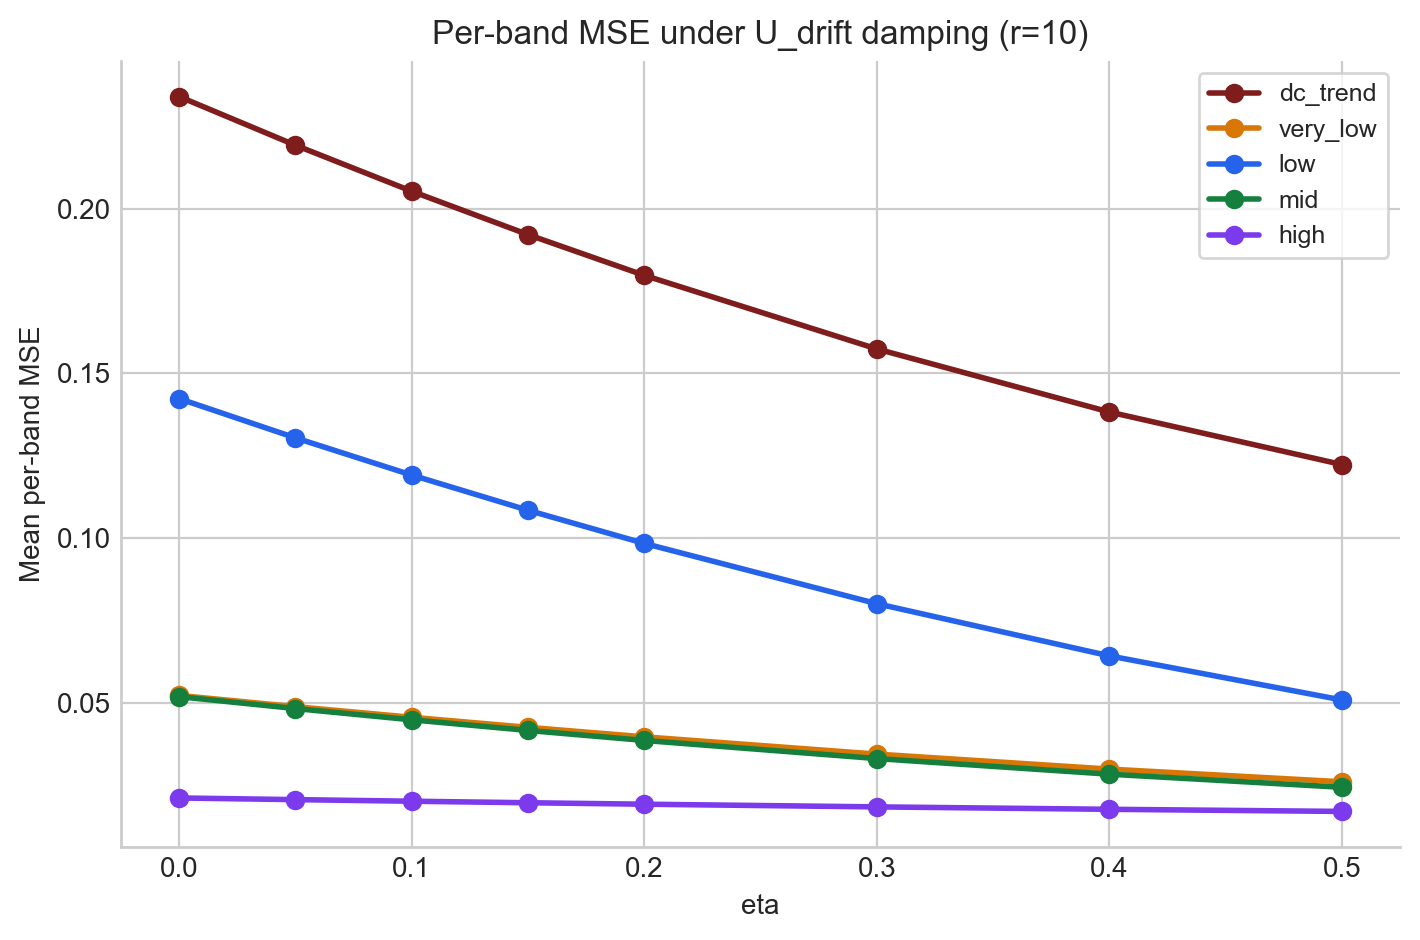

Saved results/figures/smad_eta_sweep_per_band_mse.pdf


In [2]:
band_colors = {
    'dc_trend': '#7f1d1d',
    'very_low': '#d97706',
    'low': '#2563eb',
    'mid': '#15803d',
    'high': '#7c3aed',
}

fig, ax = plt.subplots(figsize=(7.2, 4.8), dpi=200)
for band in bands:
    values = [item['band_mse'][band] for item in best_items]
    ax.plot(etas, values, marker='o', linewidth=2, color=band_colors[band], label=band)
ax.set_xlabel('eta')
ax.set_ylabel('Mean per-band MSE')
ax.set_title(f'Per-band MSE under U_drift damping (r={best_r})')
ax.legend(frameon=True, fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
fig.tight_layout()
path = FIGURE_DIR / 'smad_eta_sweep_per_band_mse.pdf'
fig.savefig(path, bbox_inches='tight')
plt.show()
print(f"Saved {path.relative_to(REPO_ROOT)}")

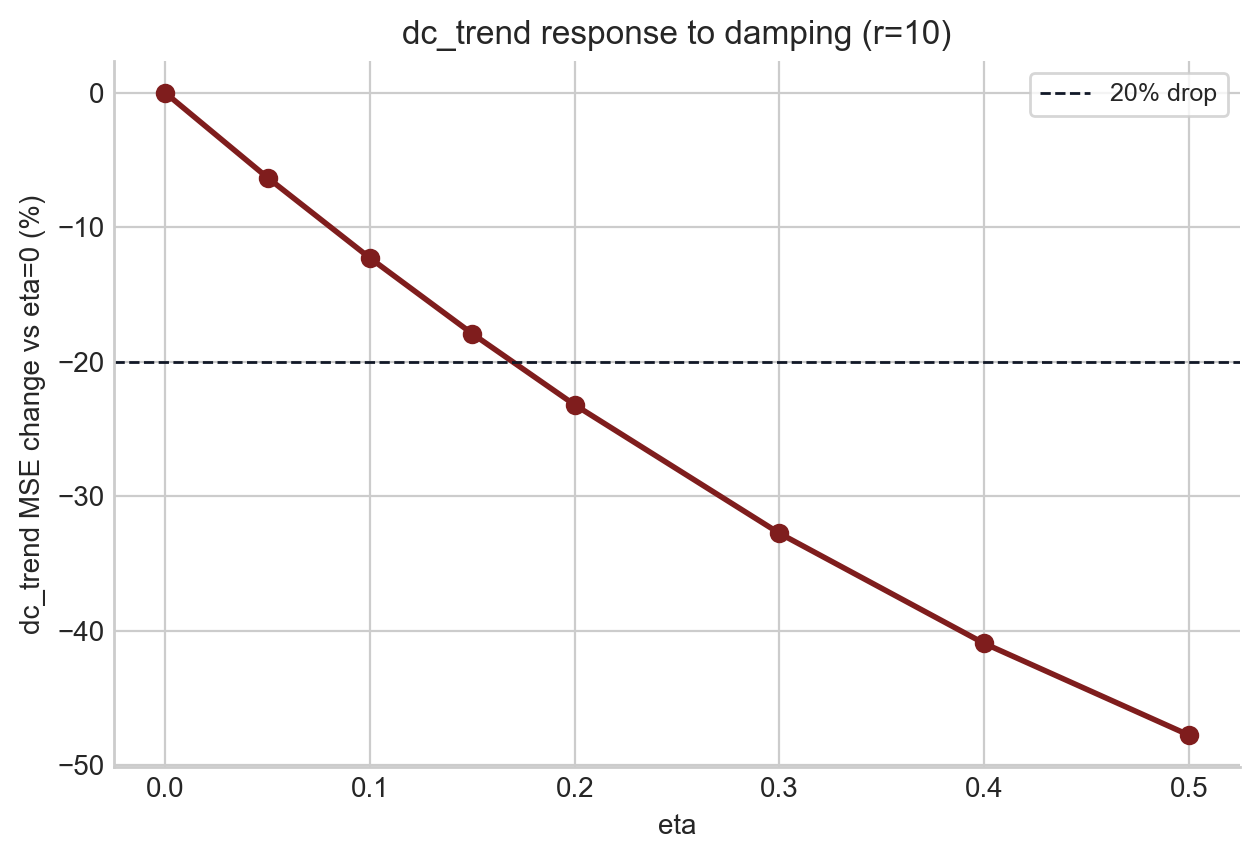

Saved results/figures/smad_eta_sweep_dc_change.pdf


In [3]:
dc_change = [item['dc_trend_change_pct'] for item in best_items]

fig, ax = plt.subplots(figsize=(6.4, 4.4), dpi=200)
ax.plot(etas, dc_change, marker='o', linewidth=2, color='#7f1d1d')
ax.axhline(-20, color='#111827', linestyle='--', linewidth=1, label='20% drop')
ax.set_xlabel('eta')
ax.set_ylabel('dc_trend MSE change vs eta=0 (%)')
ax.set_title(f'dc_trend response to damping (r={best_r})')
ax.legend(frameon=True, fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
fig.tight_layout()
path = FIGURE_DIR / 'smad_eta_sweep_dc_change.pdf'
fig.savefig(path, bbox_inches='tight')
plt.show()
print(f"Saved {path.relative_to(REPO_ROOT)}")

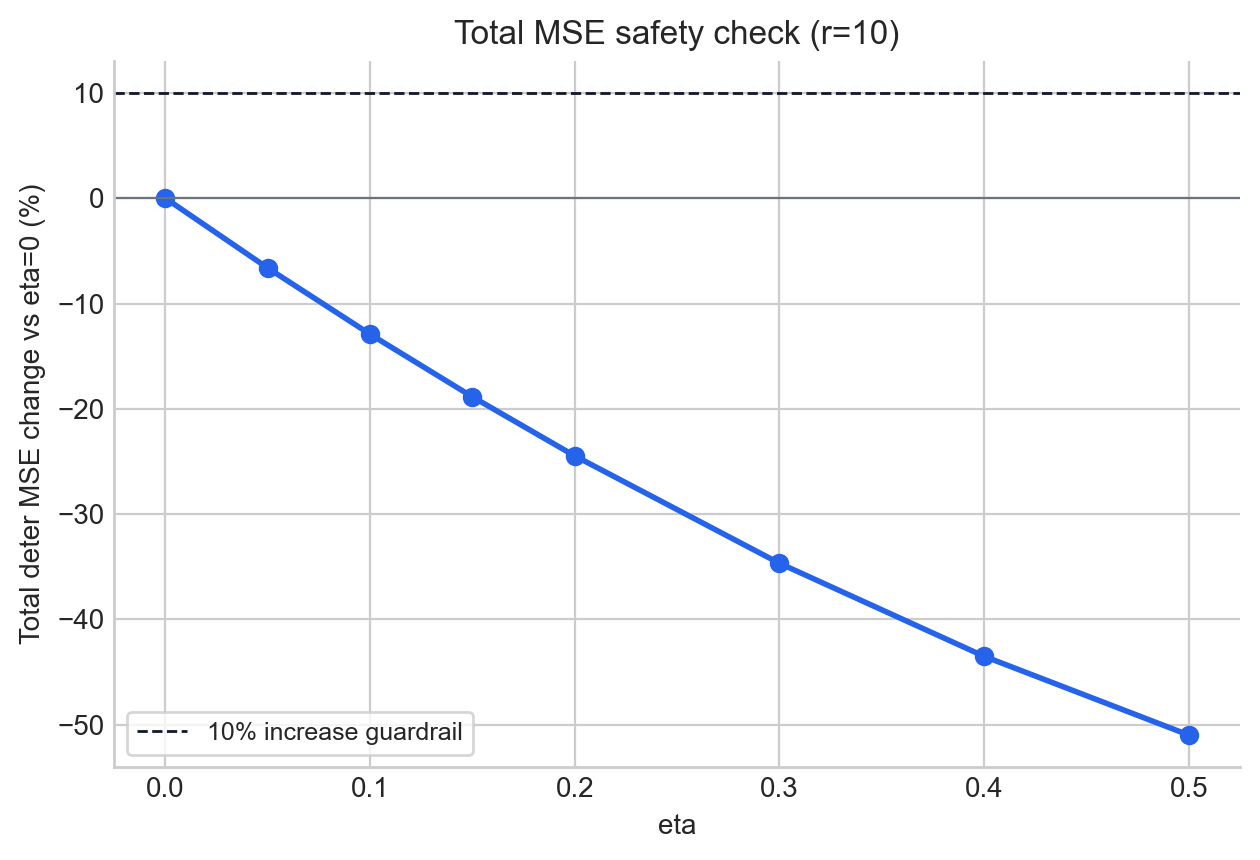

Saved results/figures/smad_eta_sweep_total_change.pdf


In [4]:
total_change = [item['total_change_pct'] for item in best_items]

fig, ax = plt.subplots(figsize=(6.4, 4.4), dpi=200)
ax.plot(etas, total_change, marker='o', linewidth=2, color='#2563eb')
ax.axhline(10, color='#111827', linestyle='--', linewidth=1, label='10% increase guardrail')
ax.axhline(0, color='#6b7280', linewidth=0.8)
ax.set_xlabel('eta')
ax.set_ylabel('Total deter MSE change vs eta=0 (%)')
ax.set_title(f'Total MSE safety check (r={best_r})')
ax.legend(frameon=True, fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
fig.tight_layout()
path = FIGURE_DIR / 'smad_eta_sweep_total_change.pdf'
fig.savefig(path, bbox_inches='tight')
plt.show()
print(f"Saved {path.relative_to(REPO_ROOT)}")

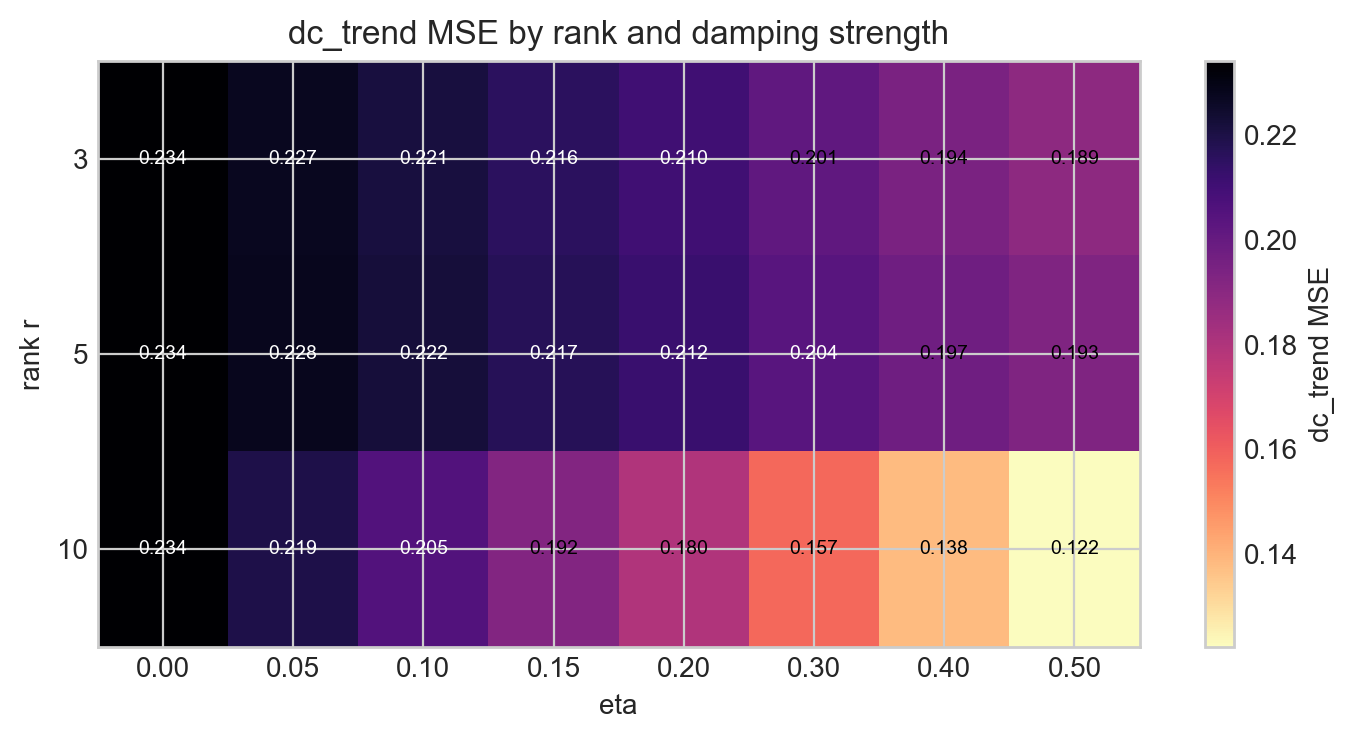

Saved results/figures/smad_eta_sweep_dc_heatmap.pdf


In [5]:
heatmap = np.array([
    [item['dc_trend_mse'] for item in result['rank_results'][str(rank)]['eta_results']]
    for rank in ranks
], dtype=float)

fig, ax = plt.subplots(figsize=(7.2, 3.8), dpi=200)
im = ax.imshow(heatmap, aspect='auto', cmap='magma_r')
ax.set_xticks(np.arange(len(etas)))
ax.set_xticklabels([f'{eta:.2f}' for eta in etas])
ax.set_yticks(np.arange(len(ranks)))
ax.set_yticklabels([str(rank) for rank in ranks])
ax.set_xlabel('eta')
ax.set_ylabel('rank r')
ax.set_title('dc_trend MSE by rank and damping strength')
for i in range(len(ranks)):
    for j in range(len(etas)):
        ax.text(j, i, f'{heatmap[i, j]:.3f}', ha='center', va='center', color='white' if heatmap[i, j] > heatmap.mean() else 'black', fontsize=7)
fig.colorbar(im, ax=ax, label='dc_trend MSE')
fig.tight_layout()
path = FIGURE_DIR / 'smad_eta_sweep_dc_heatmap.pdf'
fig.savefig(path, bbox_inches='tight')
plt.show()
print(f"Saved {path.relative_to(REPO_ROOT)}")